In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Tunable Filter Cavity
Three-mirror Fabry–Perot cavities (3MCs) exhibit richer and more tunable resonance structures than standard two-mirror cavities, due to the interference between their two sub-cavities.

<p align="center">
  <img src="threemirrorcavity.png" width="500"/>
</p>

The corresponding wavefunctions are given by:

<p align="center">
  <img src="threemirrorwavefunctions.png" width="500"/>
</p>


https://ccahilla.github.io/fabryperot.html

### Elements of the Three-Mirror System


#### 1. Mirror Reflectivities and Transmissivities

Each mirror \( M_i \) has:

$$
R_i = \text{Power reflectivity}, \quad T_i = 1 - R_i = \text{Power transmissivity}
$$

Amplitude coefficients:

$$
r_i = \sqrt{R_i}, \quad t_i = \sqrt{1 - R_i}
$$

#### 2. Subcavity Lengths

The three-mirror cavity is composed of two coupled subcavities:

$$
L_1 = \text{distance between } M_1 \text{ and } M_2 \\
L_2 = \text{distance between } M_2 \text{ and } M_3
$$

Each subcavity can resonate independently, and the coupling through M_2 gives rise to mode splitting.

---

Parameters:
$$
\lambda = 1064\,\text{nm}
$$

$$
L_1 = 1\,\text{m}, \quad L_2 = 3\,\text{m}
$$

$$
\Delta\nu \in [-155, 155]\,\text{MHz}
$$

$$
k = k_0 + \Delta k = \frac{2\pi}{c}(\nu_0 + \Delta\nu), \quad \text{where} \quad \nu_0 = \frac{c}{\lambda}
$$


In [2]:
#Constants + Parameters
c = 3e8                      
lambda0 = 1063.999e-9           
nu0 = c / lambda0            
k0 = 2 * np.pi / lambda0     
#Frequency detuning (Δν from -150 MHz to 150 MHz)
dnu = np.linspace(-200e6, 200e6, 1000)
nu = nu0+dnu
k = 2*np.pi*nu/c 


The transmitted field amplitude $t$ for a three-mirror Fabry-Perot cavity is given by:

$$
t = \frac{-t_1 t_2 t_3 \, e^{i k (L_1 + L_2)}}{e^{2i k (L_1 + L_2)} - r_1 r_2 \, e^{2i k L_2} - r_2 r_3 \, e^{2i k L_1} + r_1 r_3 (r_2^2 + t_2^2)}
$$

Where:
- $r_i$ is the amplitude reflectivity of mirror $i$  
- $t_i$ is the amplitude transmissivity of mirror $i$  
- $L_1$ and $L_2$ are the sub-cavity lengths  
- $k = \frac{2\pi}{\lambda}$ is the wave number



In [3]:
def T_three_mirror(k,L1,L2,R1,R2,R3):
    r1,r2,r3 = np.sqrt(R1), np.sqrt(R2), np.sqrt(R3)
    t1,t2,t3 = np.sqrt(1-R1), np.sqrt(1-R2), np.sqrt(1-R3) 
    # Phase terms
    e_total = np.exp(2j*k*(L1+L2))
    e_L2 = np.exp(2j*k*L2)
    e_L1 = np.exp(2j*k*L1)

    num = -t1*t2*t3*np.exp(1j*k*(L1+L2))
    denom = (e_total - r1*r2*e_L2 - r2*r2*e_L1 + r1*r3*(r2**2+t2**2))

    return np.abs(num / denom)**2

The standard Fabri-Perot Transmission Formula is given by:
$$
T_{\text{FP}} = \frac{T_1 T_2}{1 + R_1 R_2 - 2\sqrt{R_1 R_2} \cos(2kL)}
$$


In [4]:
#Standard Fabri-Perot Cavity
def T_fp(k, L,R1, R2):
    T1,T2 = 1-R1, 1-R2
    delta = 2*k*L
    return (T1*T2)/(1+ R1*R2 - 2*np.sqrt(R1*R2)*np.cos(delta))

def compute_fwhm(x, y):
    half_max = np.max(y) / 2.0
    indices = np.where(y >= half_max)[0]
    if len(indices) < 2:
        return 0.0
    fwhm = x[indices[-1]] - x[indices[0]]
    return fwhm

### L1 = 1 m , L2 = 3 m

In [5]:
#Compute spectra
R_test = 0.9
L1_test = 1
L2_test = 3
T3 = T_three_mirror(k, L1_test, L2_test, R_test, R_test, R_test)
TFP1 = T_fp(k, L1_test,R_test,R_test)
TFP3 = T_fp(k, L2_test,R_test,R_test)

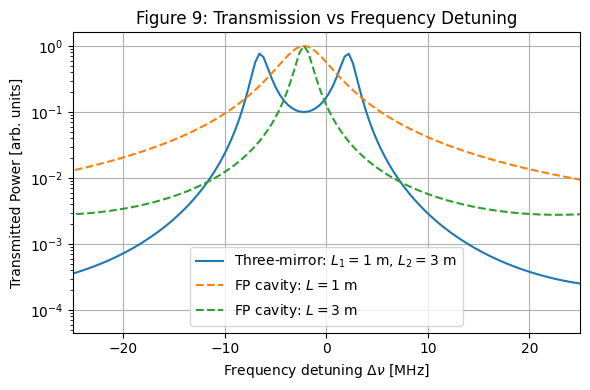

In [6]:
#Plots
plt.figure(figsize=(6, 4))
plt.semilogy(dnu*1e-6, T3, label='Three-mirror: $L_1=1$ m, $L_2=3$ m')
plt.semilogy(dnu*1e-6, TFP1, '--', label='FP cavity: $L=1$ m')
plt.semilogy(dnu*1e-6, TFP3, '--', label='FP cavity: $L=3$ m')

plt.xlabel("Frequency detuning $\\Delta\\nu$ [MHz]")
plt.ylabel("Transmitted Power [arb. units]")
plt.title("Figure 9: Transmission vs Frequency Detuning")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.xlim(-25,25)
plt.show()

### L1 = 2 m , L2 = 2 m

In [7]:
#Compute spectra
T3_2 = T_three_mirror(k, 2,2,R_test,R_test,R_test)
TFP_2 = T_fp(k,2,R_test,R_test)

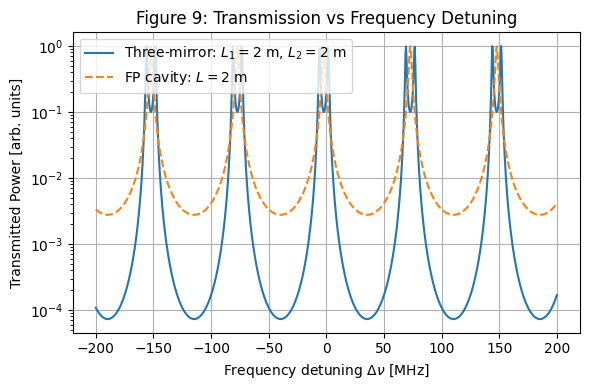

In [8]:
#Plots
plt.figure(figsize=(6, 4))
plt.semilogy(dnu*1e-6, T3_2, label='Three-mirror: $L_1=2$ m, $L_2=2$ m')
plt.semilogy(dnu*1e-6, TFP_2, '--', label='FP cavity: $L=2$ m')
#plt.semilogy(dnu*1e-6, TFP2, '--', label='FP cavity: $L=3$ m')

plt.xlabel("Frequency detuning $\\Delta\\nu$ [MHz]")
plt.ylabel("Transmitted Power [arb. units]")
plt.title("Figure 9: Transmission vs Frequency Detuning")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Bandwidth Tuning via Thermal Expansion

We model a three-mirror filter cavity as an effective two-mirror system (L_1 << L_2), where mirrors R_1 and R_2 are a thick mirror substrate that forms a subcavity of length L_1. Thermal expansion of this segment modulates the effective reflectivity and tunes the total cavity bandwidth.

Assuming $$R_1 = R_2 = R_{12},$$ the bandwidth of the system is approximately:

$$
\gamma = \frac{c}{8\pi L_2} \left( \frac{(1 - R_{12})^2}{1 - 2R_{12} \cos\left( \frac{4\pi L_1}{\lambda} \right) + R_{12}^2} + (1 - R_3) \right)
$$

Thermal tunability is achieved through the derivative:

$$
\frac{d\gamma}{dL_1} = \frac{c}{8\pi L_2} \cdot \frac{dT_{\text{eff}}}{d\phi} \cdot \frac{d\phi}{dL_1}, \quad \text{where } \phi = \frac{4\pi L_1}{\lambda}
$$

The effective reflectivity term \( T_{\text{eff}} \) has sensitivity:

$$
\frac{dT_{\text{eff}}}{d\phi} = -\frac{(1 - R_{12})^2 \cdot 2R_{12} \sin\left( \frac{4\pi L_1}{\lambda} \right)}{\left[1 - 2R_{12} \cos\left( \frac{4\pi L_1}{\lambda} \right) + R_{12}^2 \right]^2}
$$

The thermal tunability in Hz/°C is then:

$$
\text{Tunability} = \frac{d\gamma}{dL_1} \cdot \frac{dL_1}{dT}, \quad \text{where } \frac{dL_1}{dT} = \alpha \cdot L_1
$$

We target tunability of a few hundred Hz over a 10 °C swing, with baseline bandwidths from 10–500 kHz. This method scales well to long cavities—e.g., a 300 m cavity with a thin tuning optic L_1 of few mm retains high finesse while achieving controllable bandwidth variation.

<p align="center">
  <img src="tunablecavity.png" width="700"/>
</p>


Notes: L1- a tunable etalon (flat-flat fused silica substrate, thermally tunable), L2- long cavity section forming a planar-concave resonator

In [9]:
def BW_tunability(L1,L2,R1,R3,lamb=1064e-9, tunability=0.55, heating_capacity=10):
    """
       Compute the baseline bandwidth and thermal tunability of a 3-mirror filter cavity.
    Parameters:
        L1: Thickness of tuning optic (m)
        L2: Cavity length (m)
        R1, R2, R3: Mirror reflectivities (unitless)
        lamb: Wavelength (m)cccc
        tunability: Thermal expansion coeff. (1/K)
        heating_capacity: Max temp swing (K)
    Returns:
        baseline_bw: Hz
        bw_expansion: Hz/K
        dL1_dT: m/K
        dgamma_dL1: Hz/m
    """
    c = 3e8
    prefactor = c/(8*np.pi*L2)
    num = (1-R1)*(1-R1)
    denom = 1-2*R1*np.cos(4*np.pi*L1/lamb)+R1**2
    baseline_bw = prefactor*(num/denom + (1-R3))

    # Temperature Tunability
    dL1_dT = tunability*1e-6 * L1 
    #dTeff_dphi = (2 * R12*(1-R12)*(1-R12))/(1+R12*R12)**2 # at quadrature (phi = pi/2)
    dTeff_dphi = -num*(2*R1*np.sin(4*np.pi*L1/lamb))/(denom**2)
    dgamma_dL1 = prefactor * dTeff_dphi * (4*np.pi/lamb)
    bw_expansion = dgamma_dL1 * dL1_dT

    return baseline_bw, bw_expansion, dL1_dT, dgamma_dL1 

def plot_dTeff_dphi(R12, L1, lamb=1064e-9):
    num = (1-R12)**2
    denom = 1-2*R12*np.cos(4*np.pi*L1/lamb)+R12**2
    dTeff_dphi = -num*(2*R12*np.sin(4*np.pi*L1/lamb))/(denom**2)
    return dTeff_dphi

def T_3_mirror(k,L1,L2,R1,R2,R3):
    # Phase terms
    r1,r2,r3 = np.sqrt(R1), np.sqrt(R2), np.sqrt(R3)
    t1,t2,t3 = np.sqrt(1-R1), np.sqrt(1-R2), np.sqrt(1-R3)
    
    e_total = np.exp(2j*k*(L1+L2))
    e_L2 = np.exp(2j*k*L2)
    e_L1 = np.exp(2j*k*L1)

    num = -t1*t2*t3*np.exp(1j*k*(L1+L2))
    denom = (e_total - r1*r2*e_L2 - r2*r2*e_L1 + r1*r3*(r2**2+t2**2))

    return np.abs(num / denom)**2

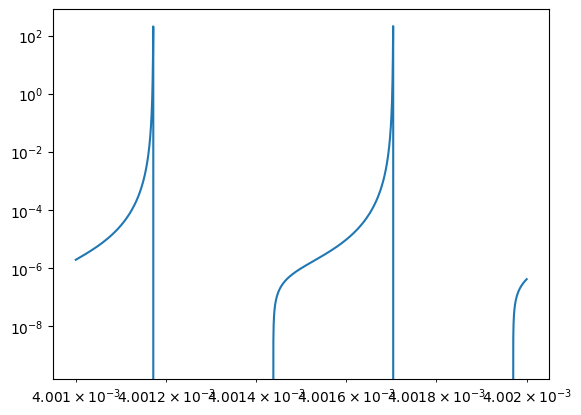

In [10]:
L1_test = np.linspace(0.004001, 0.004002, 10000) 
R12_test = 0.997

plt.loglog(L1_test, plot_dTeff_dphi(R12_test, L1_test))

### Parameter sweep for optimal L2, L2, R12, R3

In [11]:
# Sweep ranges
#L1_vals = np.linspace(0.0057, 0.0063, 100)     # 2 mm to 10 mm
L1_vals = np.linspace(0.0058, 0.0062, 100)
L2_vals = np.linspace(0.5, 2.5, 50)          # 0.5 m to 2.5 m
R1_vals = np.linspace(0.97, 0.999, 30)    
R3_vals = np.linspace(0.99, 0.9999, 10)

results = []

for L1 in L1_vals: 
    for L2 in L2_vals:
        for R1 in R1_vals:
            for R3 in R3_vals:
                bw, bw_per_K, dL1_dT, dgamma_dL1 = BW_tunability(L1, L2, R1, R3)
                #print(f"bw={bw/1e3:.2f} kHz, bw_per_K={bw_per_K:.2f} Hz/K")
                if 10e3 <= bw <= 500e3 and 10 <= bw_per_K <= 50:
                    results.append((L1, L2, R1, R3, bw, bw_per_K))

# Sort by tunability
results.sort(key=lambda x: x[-1], reverse=True)

# Display top matches
for r in results[30:50]:
    print(f"L1={r[0]*1e3:.5f} mm, L2={r[1]:.5f} m, R1=R2={r[2]:.4f}, R3={r[3]:.5f}, BW={r[4]/1e3:.1f} kHz, Tunability/°C={r[5]:.1f} Hz")

# Create DataFrame
df = pd.DataFrame(results, columns=["L1 (m)", "L2 (m)", "R1 = R2", "R3", "Baseline BW (Hz)", "Tunability/°C (Hz)"])

# Save to CSV
df.to_csv("cavity_tunability_results1.csv", index=False)

print("Saved results to 'cavity_tunability_results1.csv'")

L1=5.96566 mm, L2=0.78571 m, R1=R2=0.9760, R3=0.99550, BW=71.1 kHz, Tunability/°C=50.0 Hz
L1=5.96566 mm, L2=0.78571 m, R1=R2=0.9760, R3=0.99660, BW=54.4 kHz, Tunability/°C=50.0 Hz
L1=5.96566 mm, L2=0.78571 m, R1=R2=0.9760, R3=0.99770, BW=37.7 kHz, Tunability/°C=50.0 Hz
L1=5.96566 mm, L2=0.78571 m, R1=R2=0.9760, R3=0.99880, BW=21.0 kHz, Tunability/°C=50.0 Hz
L1=6.11515 mm, L2=0.78571 m, R1=R2=0.9770, R3=0.99000, BW=154.5 kHz, Tunability/°C=50.0 Hz
L1=6.11515 mm, L2=0.78571 m, R1=R2=0.9770, R3=0.99110, BW=137.8 kHz, Tunability/°C=50.0 Hz
L1=6.11515 mm, L2=0.78571 m, R1=R2=0.9770, R3=0.99220, BW=121.1 kHz, Tunability/°C=50.0 Hz
L1=6.11515 mm, L2=0.78571 m, R1=R2=0.9770, R3=0.99330, BW=104.3 kHz, Tunability/°C=50.0 Hz
L1=6.11515 mm, L2=0.78571 m, R1=R2=0.9770, R3=0.99440, BW=87.6 kHz, Tunability/°C=50.0 Hz
L1=6.11515 mm, L2=0.78571 m, R1=R2=0.9770, R3=0.99550, BW=70.9 kHz, Tunability/°C=50.0 Hz
L1=6.11515 mm, L2=0.78571 m, R1=R2=0.9770, R3=0.99660, BW=54.2 kHz, Tunability/°C=50.0 Hz
L1=6.1

In [12]:
def plot_bw_expansion(L1_best, L2_best, R1_best, R3_best):
    baseline_bw, bw_expansion, dL1_dT, dgamma_dL1 = BW_tunability(L1_best, L2_best, R1_best, R3_best)
    print(f"L1 : {L1_best} m, Pole: {baseline_bw} Hz, Bandwidth Tunability: {bw_expansion} Hz/°C")

    # 2. Plot multiple temperature detunings
    plt.figure(figsize=(12, 8))
    dL1_arr = [dL1_dT * T for T in np.arange(0, 11)]
    dnu_arr = np.linspace(-200e6, 200e6, 1000)
    for dL1 in dL1_arr:
        T3_test = T_3_mirror(k, L1_best + dL1, L2_best, R1_best, R1_best, R3_best)
        plt.semilogy(
            dnu_arr * 1e-6,
            T3_test,
            label=(
                f"$L_1$={L1_best + dL1:.9f} m, "
                f"$L_2$={L2_best} m, BW={baseline_bw + dgamma_dL1*dL1:.1f} Hz"
            )
        )

    # 3. Labels & legend
    plt.xlabel("Frequency detuning $\\Delta\\nu$ [MHz]")
    plt.ylabel("Transmitted Power [arb. units]")
    plt.title(
        f"Transmission vs Frequency Detuning via Temperature Tuning of L1, "
        f"R1={R1_best}, R2={R1_best}, R3={R3_best}"
    )
    plt.grid(True)
    plt.legend(loc='upper right')

    # ——————— ADD: FSR and BW annotations ———————
    #Ltot  = L1_best + L2_best             # total cavity length
    FSR   = 3e8 / (2 * L2_best)           # free spectral range in Hz
    FSR_L2_MHz = FSR * 1e-6
    #BW_MHz  = baseline_bw * 1e-6

    # Vertical lines at ±FSR
    #plt.axvline(+FSR_MHz, color='k', ls='--', lw=1)
    #plt.axvline(-FSR_MHz, color='k', ls='--', lw=1)

    plt.text(
    0.01, 0.02,  # x and y in axis fraction
    f"FSR(L2) ≈ {FSR_L2_MHz:.3f} MHz\nPole: {baseline_bw:.3f} Hz\nTunability: {bw_expansion:.3f} Hz/C",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='gray', alpha=0.8)
    )

    plt.tight_layout()
    plt.show()

### Tunable Cavity Demonstration: L1 = 7.9 mm, L2 = 2.09 m, R12 = 0.9807, R3 = 0.9977

See cavity_tunability_results.csv for more param options

L1 : 0.00596566 m, Pole: 52561.583943650294 Hz, Bandwidth Tunability: 1004.3007279930379 Hz/°C


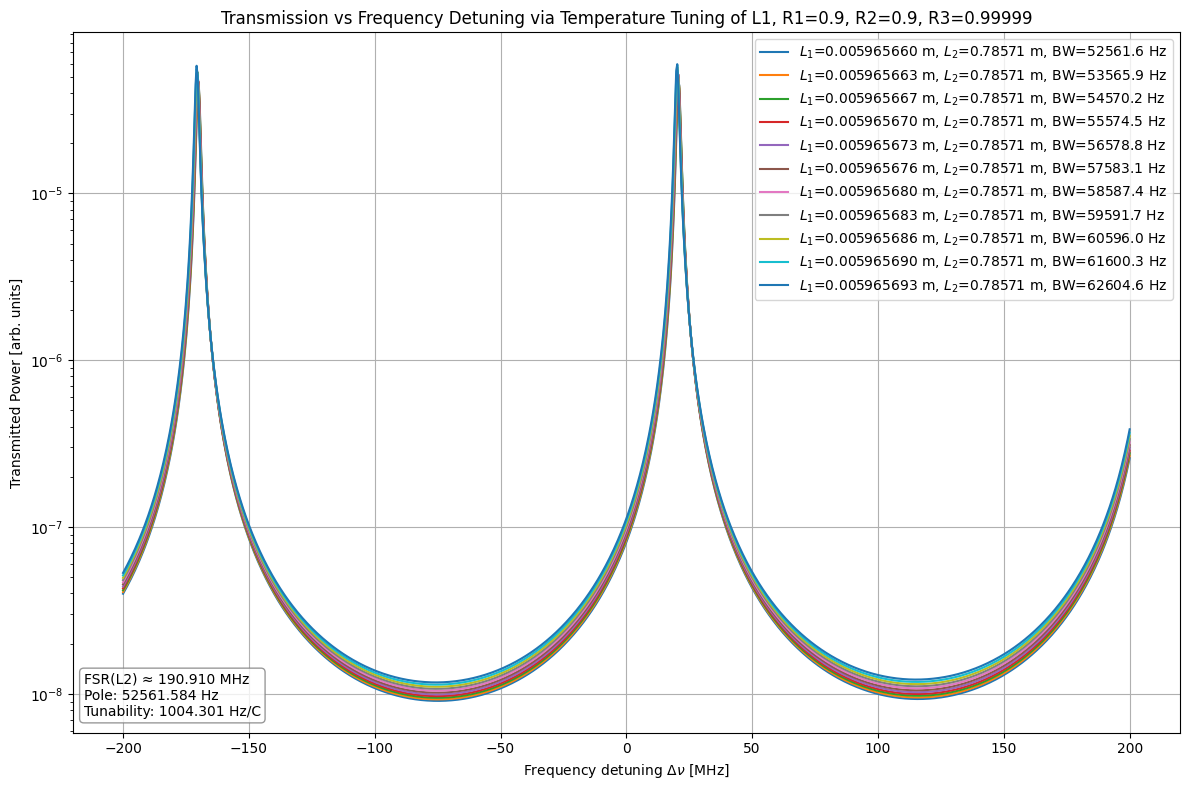

In [17]:
# L1=5.96566 mm, L2=0.78571 m, R1=R2=0.9760, R3=0.99550,
L1_best = 0.00596566
L2_best = 0.78571
R1_best = 0.90 #0.9760 #0.9888
R3_best = 0.99999

plot_bw_expansion(L1_best,L2_best,R1_best,R3_best)

In [ ]:
#0.007858585858585858,1.1122448979591835,0.9888275862068966,0.99,108140.65536974366,49.96546525712577 0.007858585858585858,1.1122448979591835 0.9888275862068966,0.9911
L1_best = 0.007858
L2_best = 1.1122
R1_best = 0.99 #0.9888 
R3_best = 0.9911

plot_bw_expansion(L1_best,L2_best,R1_best,R3_best)

### Baseline Bandwidth/Tunablity wrt L1, L2 = 2.09 m

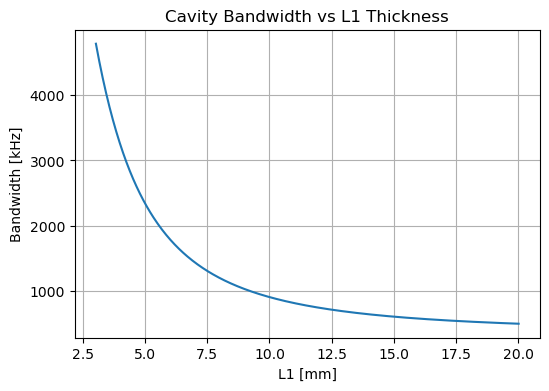

In [14]:
L1_range = np.linspace(0.003019, 0.020022, 500)
BW_vals = [BW_tunability(L1, L2_best, R1_best, R1_best, R3_best)[0] for L1 in L1_range]

plt.figure(figsize=(6, 4))
plt.plot(L1_range*1e3, np.array(BW_vals)*1e-3)
plt.xlabel("L1 [mm]")
plt.ylabel("Bandwidth [kHz]")
plt.title("Cavity Bandwidth vs L1 Thickness")
plt.grid()
plt.show()

### 300m Tunable Cavity Scaling: L1 = 7.9 mm, L2 = 297.55 m, R12 = 0.9807, R3 = 0.9977
<p align="center">
  <img src="optimal_cavity.png" width="500"/>
</p>

L1 : 0.006 m, Baseline Bandwidth: 12.724374437278872 Hz, Bandwidth Tunability: -0.6809527607853856 Hz/°C


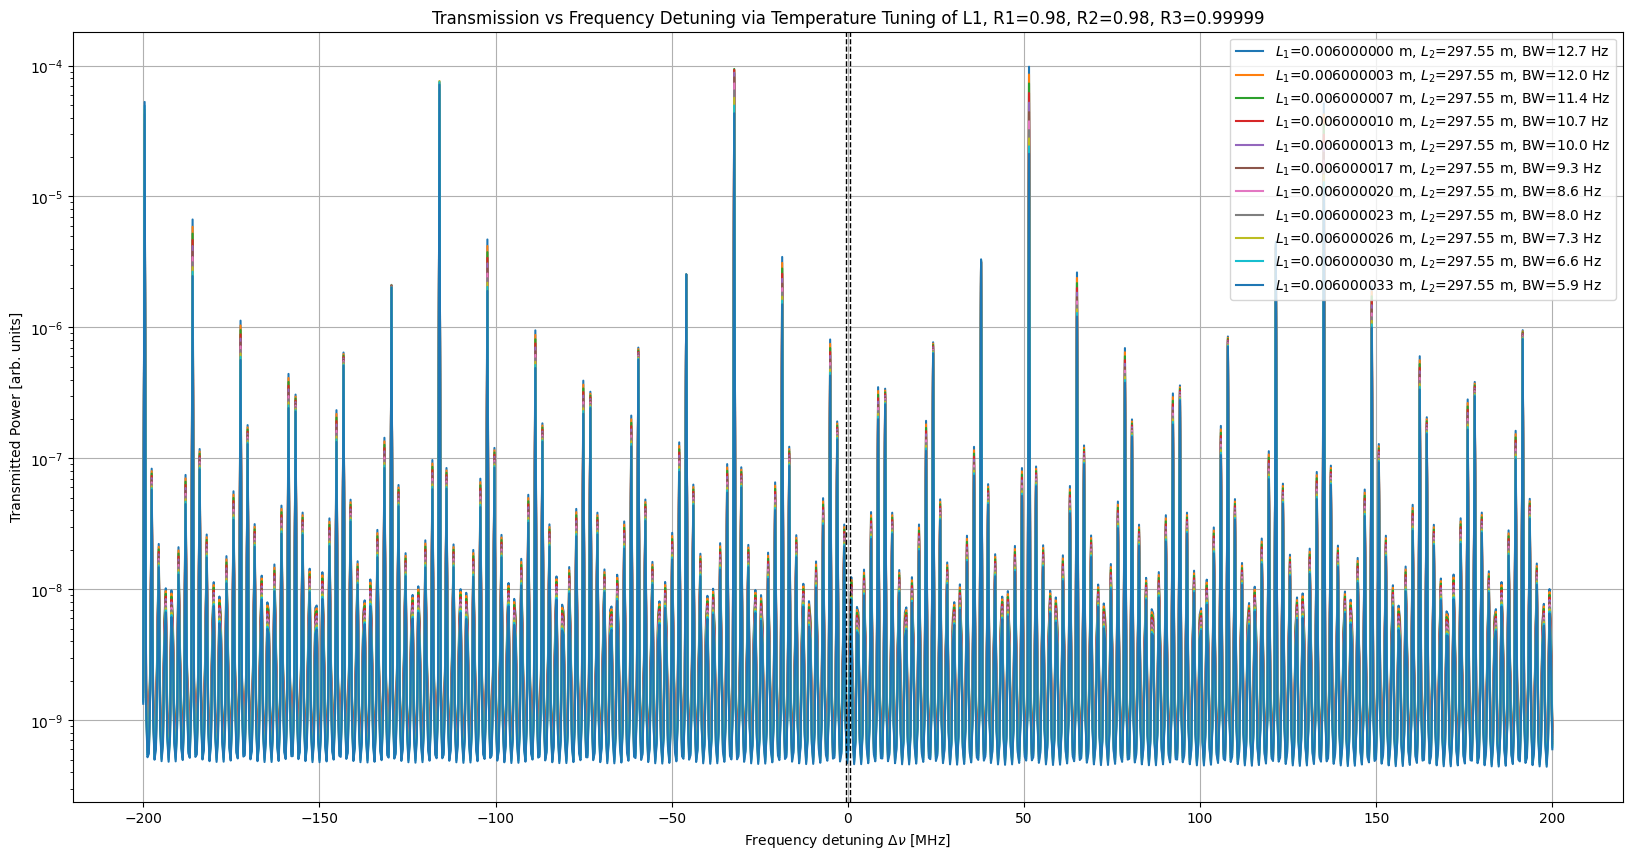

In [25]:
# 1. Set up and compute tunability
L1_official = 0.006  # 3.1 cm
L2_official = 297.55 # 300 m cavity for 3 ms storage time
R1_official = 0.98
R3_official = 1-1e-5

plot_bw_expansion(L1_official, L2_official, R1_official, R3_official)


In [ ]:
# Sweep ranges
L1_official = np.linspace(0.001, 0.07, 100)     # 2 mm to 6 cm
L2_official = 297.55                            # 297.55 m
R1_official = np.linspace(0.7, 0.999, 30)    
R3_official = 1-1e-6

results_official = []

for L1 in L1_official:
    for R1 in R1_official:
        bw, bw_per_K, dL1_dT, dgamma_dL1 = BW_tunability(L1, L2_official, R1, R3_official)
        #print(f"bw={bw/1e3:.2f} kHz, bw_per_K={bw_per_K:.2f} Hz/K")
        if 10 <= bw <= 500 and 5 <= 10*bw_per_K <= 25:
            results_official.append((L1, L2_official, R1, R3_official, bw, 10*bw_per_K))

# Sort by tunability
results_official.sort(key=lambda x: x[-1], reverse=True)

# Display top matches
for r in results_official[30:50]:
    print(f"L1={r[0]*1e3:.5f} mm, L2={r[1]:.5f} m, R1=R2={r[2]:.4f}, R3={r[3]:.5f}, BW={r[4]:.3f} Hz, Tunability/10°C={r[5]:.1f} Hz")

# Create DataFrame
df_official = pd.DataFrame(results_official, columns=["L1 (m)", "L2 (m)", "R1 = R2", "R3", "Baseline BW (Hz)", "Tunability/10°C (Hz)"])

# Save to CSV
df_official.to_csv("300mcavity_tunability_results.csv", index=False)

print("Saved results to '300mcavity_tunability_results.csv'")

L1=16.33333 mm, L2=297.55000 m, R1=R2=0.9740, R3=1.00000, BW=14.351 Hz, Tunability/10°C=15.6 Hz
L1=2.39394 mm, L2=297.55000 m, R1=R2=0.9790, R3=1.00000, BW=36.822 Hz, Tunability/10°C=15.3 Hz
L1=9.36364 mm, L2=297.55000 m, R1=R2=0.9790, R3=1.00000, BW=15.805 Hz, Tunability/10°C=15.1 Hz
L1=37.93939 mm, L2=297.55000 m, R1=R2=0.9700, R3=1.00000, BW=11.768 Hz, Tunability/10°C=14.8 Hz
L1=16.33333 mm, L2=297.55000 m, R1=R2=0.9750, R3=1.00000, BW=13.258 Hz, Tunability/10°C=14.4 Hz
L1=2.39394 mm, L2=297.55000 m, R1=R2=0.9800, R3=1.00000, BW=33.371 Hz, Tunability/10°C=13.8 Hz
L1=37.93939 mm, L2=297.55000 m, R1=R2=0.9710, R3=1.00000, BW=10.988 Hz, Tunability/10°C=13.8 Hz
L1=23.30303 mm, L2=297.55000 m, R1=R2=0.9700, R3=1.00000, BW=13.554 Hz, Tunability/10°C=13.8 Hz
L1=9.36364 mm, L2=297.55000 m, R1=R2=0.9800, R3=1.00000, BW=14.326 Hz, Tunability/10°C=13.7 Hz
L1=16.33333 mm, L2=297.55000 m, R1=R2=0.9760, R3=1.00000, BW=12.209 Hz, Tunability/10°C=13.3 Hz
L1=52.57576 mm, L2=297.55000 m, R1=R2=0.9700

In [1]:
from scipy.optimize import brentq

def R_from_Teff_quadrature(Teff_target):
    def Teff(R):
        return (1 - R)**2 / (1 + R**2)
    
    def objective(R):
        return Teff(R) - Teff_target

    R_sol = brentq(objective, 0.8, 0.999999)
    return R_sol

In [2]:
Teff_target = 0.0013296244459829337  # 909 ppm
R_opt = R_from_Teff_quadrature(Teff_target)
print(f"At quadrature, for Teff = {Teff_target}, required R1 = R2 = {R_opt:.9f}, T = {1 - R_opt:.0e}")

At quadrature, for Teff = 0.0013296244459829337, required R1 = R2 = 0.949711999, T = 5e-02


In [18]:
L2_test = 297.55  # meters
R12_test = 0.949711999
R3_test = 1 - 1e-6
lamb = 1064e-9
target_bw_range = (80, 150)  # Hz
heating_capacity = 10  # °C

In [ ]:
def BW_tunability(L1, L2, R1, R2, R3, lamb=1064e-9, tunability=0.55, heating_capacity=10):
    c = 3e8
    prefactor = c / (8 * np.pi * L2)
    num = (1 - R1)*(1 - R2)
    denom = 1 - 2 * np.sqrt(R1 * R2) * np.cos(4 * np.pi * L1 / lamb) + R1*R2
    
    baseline_bw = prefactor * (num / denom) + prefactor * (1 - R3)

    dL1_dT = tunability * 1e-6 * L1 
    dTeff_dphi = -num * (2 * np.sqrt(R1*R2) * np.sin(4 * np.pi * L1 / lamb)) / (denom**2)
    dgamma_dL1 = prefactor * dTeff_dphi * (4 * np.pi / lamb)
    bw_expansion = dgamma_dL1 * dL1_dT
    print(f"BW: {baseline_bw}, tunability: {bw_expansion}")

    return baseline_bw, bw_expansion, dL1_dT, dgamma_dL1 

BW_tunability(L1=0.004474386,L2=297.5, R1 = , R2 = , R3=(1-1e-6))

TypeError: BW_tunability() missing 2 required positional arguments: 'R1' and 'R2'

In [20]:
# Sweep over L1 values
L1_vals = np.linspace(0.02, 0.04, 1000)
results = []

for L1 in L1_vals:
    bw, bw_tunability, dL1_dT, dgamma_dL1 = BW_tunability(L1, L2_test, R12_test, R3_test)
    if target_bw_range[0] <= bw_tunability*heating_capacity <= target_bw_range[1]:
        results.append((L1, bw, bw_tunability))

# Find the L1 with maximum tunability within range
if results:
    optimal = max(results, key=lambda x: x[2])
else:
    optimal = None

df = pd.DataFrame(results, columns=["L1 (m)", "Baseline Bandwidth (Hz)", "Bandwidth Tunability (Hz/°C)"])
df.sort_values("Bandwidth Tunability (Hz/°C)",ascending=False)
df

,L1 (m),Baseline Bandwidth (Hz),Bandwidth Tunability (Hz/°C)
0,0.020120,63.099121,9.613743
1,0.020501,63.431202,9.891891
2,0.020881,63.766556,10.174857
3,0.021261,64.105224,10.462732
4,0.021642,64.447248,10.755604
5,0.022022,64.792671,11.053565
6,0.022402,65.141536,11.356709
7,0.022783,65.493888,11.665133
8,0.023163,65.849772,11.978934
9,0.023544,66.209232,12.298213


L1 : 0.038979 m, Baseline Bandwidth: 75.23040177090147 Hz, Bandwidth Tunability: 25.641551921319916 Hz/°C


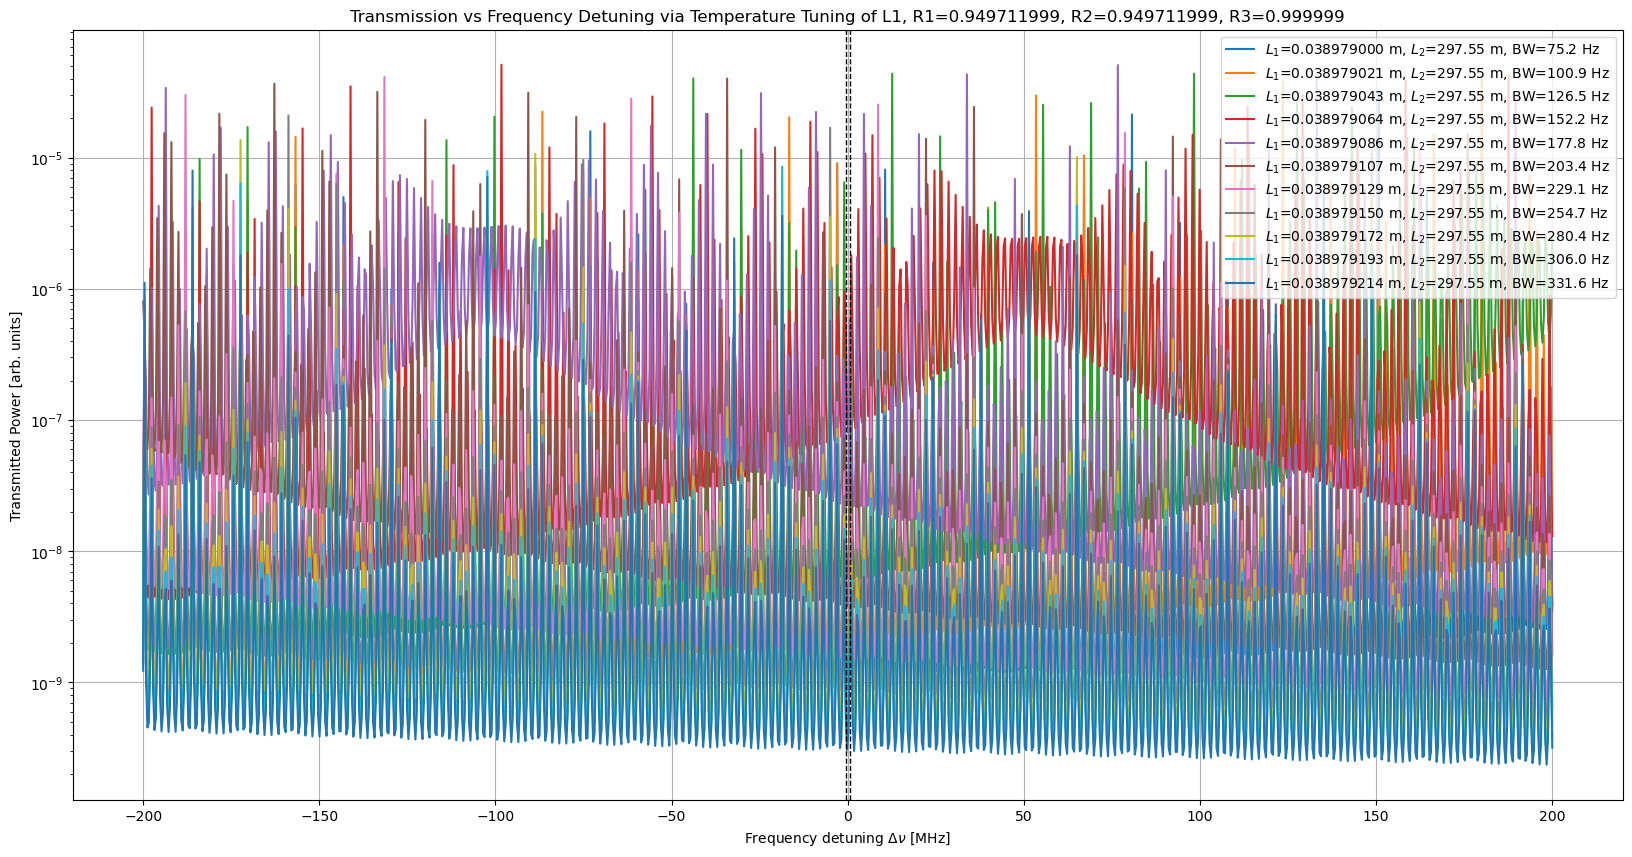

In [21]:
L2 = 297.55  # meters
R12 = 0.949711999
R3 = 1 - 1e-6
L1_test = 0.038979	
plot_bw_expansion(L1_test,L2,R12,R3)

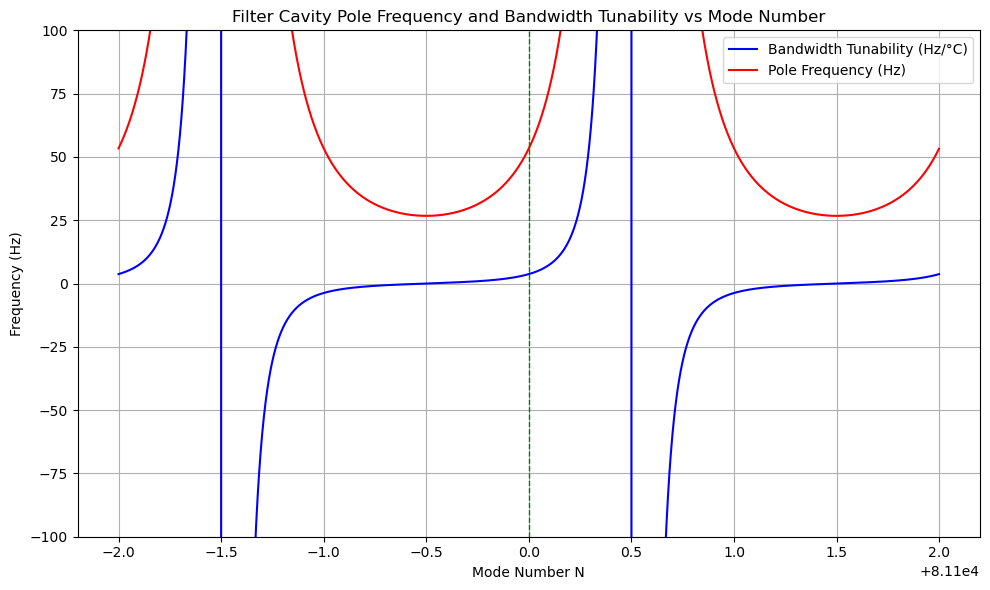

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 3e8
L2 = 297.5
lambda0 = 1064e-9
tunability = 0.55e-6
R1 = 0.949525173
R2 = 0.949899050
sqrtR = np.sqrt(R1 * R2)
k = 2 * np.pi / lambda0

# Mode numbers N (integers)
N_vals = np.arange(81098, 81102,1e-3)

# --- Bandwidth Tunability Calculation ---
def bw_tuning(R1,R2,N_vals):
    phi = ((2 * N_vals + 3) / 2) * np.pi
    num = -(1 - R1) * (1 - R2) * 2 * sqrtR * np.sin(phi)
    denom = (1 - 2 * sqrtR * np.cos(phi) + R1 * R2)**2
    dTeff_dphi = num / denom

    L1 = ((2 * N_vals + 3) / 2) * lambda0 / 4 
    dL1_dT = tunability * L1
    prefactor = c / (4 * L2 * lambda0)
    dgamma_dL1 = prefactor * dTeff_dphi
    tune = dgamma_dL1 * dL1_dT
    return tune

# --- G(N) Calculation ---
def pole(R1, R2, L2, N_vals):
    phi = ((2 * N_vals + 3) / 2) * np.pi
    sqrtRb = np.sqrt(R1 * R2)
    numerator = (1 - R1) * (1 - R2)
    denominator = 1 - 2 * sqrtRb * np.cos(phi) + R1 * R2
    BW = c / (8 * np.pi * L2) * (1e-6 + (numerator / denominator))
    return BW

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(N_vals, bw_tuning(R1,R2,N_vals), label='Bandwidth Tunability (Hz/°C)', color='blue')
plt.plot(N_vals, pole(R1,R2,L2,N_vals), label='Pole Frequency (Hz)', color='red')
plt.axvline(x=81100, color='green', linestyle='--', linewidth=1)
plt.xlabel('Mode Number N')
plt.ylabel('Frequency (Hz)')
plt.ylim(-100,100)
plt.title('Filter Cavity Pole Frequency and Bandwidth Tunability vs Mode Number')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
